# ANALÍTICA EMPRESARIAL INTEGRADA
## LABORATORIO DIRIGIDO N.° 06

### DISEÑO Y ANÁLISIS DE UN EXPERIMENTO A/B

**Semana 6 · TECSUP 2026-II**  
**Docente:** Pilar Rocío Sayán Mejía  
**Carrera:** Big Data y Ciencia de Datos  
**Plataforma de trabajo:** Google Colab

### Pregunta orientadora

**¿Qué evidencia estadística y práctica necesitamos antes de implementar una variante B?**

> Este notebook acompaña el trabajo desarrollado durante la clase. No es un informe ni un proyecto para exponer. Las celdas alternan explicación breve, ejecución guiada, interpretación y retos de cierre.

**Versión resuelta del laboratorio.** Se conservan las preguntas y el caso base.
Las devoluciones se agregan como una variable simulada adicional para revisar el
umbral académico de 4 %. Todo resultado de NexaCommerce procede de simulación;
no equivale a evidencia de una empresa real.


# I. Elemento de la capacidad terminal de la semana

Diseña y analiza un experimento A/B identificando el factor, sus niveles, el control, el tratamiento, la unidad experimental y la variable respuesta. Formula las hipótesis estadísticas, establece la métrica primaria, los guardrails, el nivel de significación, la potencia y el efecto mínimo detectable; finalmente, integra la evidencia estadística con la relevancia práctica para sustentar una decisión.


# II. Seguridad y condiciones de trabajo

- Utilice únicamente Google Colab y las fuentes indicadas por la docente.
- No modifique ni fabrique resultados para forzar una conclusión.
- Ejecute las celdas en el orden propuesto y documente cualquier error o dato ausente.
- No comparta claves, credenciales ni información personal en el notebook.
- Mantenga la estación de trabajo ordenada y no instale software no autorizado.


# III. Fundamento teórico
Un A/B test compara un control A con una variante B mediante asignación aleatoria. La unidad experimental de este caso es el usuario, que conserva su variante durante toda la observación. La aleatorización favorece la comparabilidad en expectativa; no garantiza grupos idénticos.

La respuesta es binaria: compra dentro de los siete días posteriores a la asignación. Todos los usuarios completan esa ventana antes del análisis. La métrica primaria es la proporción de usuarios que compran. Se estudia la diferencia de dos proporciones, no ANOVA.

El MDE es el efecto utilizado para planificar la potencia. El umbral empresarial es la mejora que justificaría interés práctico. Aquí son distintos: MDE de 1,5 pp y umbral empresarial de 1,0 pp. La muestra se dimensiona para detectar el MDE frente a cero, no para garantizar evidencia de superar el umbral empresarial.

Se usa una aproximación normal de Wald para la diferencia. El contraste unilateral al 5 % y el límite inferior unilateral del 95 % utilizan el mismo error estándar. También se muestra un IC bilateral del 95 % como descripción de incertidumbre; no se exige que este último excluya cero para reproducir el contraste unilateral.

La recomendación académica requiere evidencia de superar el umbral empresarial y de mantener el guardrail dentro del margen predefinido. Son criterios más exigentes que obtener p < 0,05 frente a cero. Un resultado no concluyente no demuestra igualdad.


# IV. Normas y buenas prácticas empleadas

- Prerregistro lógico: definir hipótesis, métrica, MDE y regla de decisión antes de observar los resultados.
- Aleatorización: evitar que la asignación dependa de características de las unidades.
- Trazabilidad: conservar la fuente, las transformaciones y los parámetros utilizados.
- Reproducibilidad: ejecutar el análisis mediante código verificable.
- No realizar *peeking*: no detener o prolongar el experimento solo porque el resultado momentáneo conviene.
- No contaminar grupos: una unidad debe recibir únicamente la variante asignada.
- Distinguir asociación, evidencia experimental y decisión práctica.


# V. Recursos
- Computadora, Google Colab y notebook LAB-D6-AEI-PSAYAN-2026-02.ipynb.
- Librerías numpy, pandas, scipy, statsmodels y matplotlib.
- Caso ficticio NexaCommerce con datos simulados generados en el propio notebook. No requiere descargar un dataset externo.

## Naturaleza de los datos utilizados
Los registros son sintéticos y reproducibles mediante una semilla fija. Representan usuarios de un checkout; no proceden de una empresa real. Las probabilidades del simulador son supuestos académicos, no evidencia observada. No cambie la semilla para buscar un resultado favorable. En un estudio real, los datos procederían de registros del experimento y el plan se documentaría antes de recogerlos.


# VI. Metodología para el desarrollo de la sesión

El laboratorio se desarrolla mediante una secuencia guiada de cinco momentos:

1. **Comprender:** recuperar el vocabulario esencial.
2. **Representar:** traducir el caso a la estructura de un diseño experimental.
3. **Formular:** establecer las hipótesis y la regla de decisión antes de observar resultados.
4. **Ejecutar e interpretar:** correr el código por etapas y explicar cada salida.
5. **Decidir y transferir:** integrar evidencia estadística, umbral empresarial y guardrails; luego resolver retos breves.

No se solicita exposición, informe ni trabajo adicional. La evidencia de aprendizaje se construye durante la clase mediante respuestas breves en las pausas de análisis.


# VII. Procedimiento
## Actividad 1 — Activación conceptual

| Concepto | Respuesta aplicada al caso | Pregunta de apoyo resuelta |
|---|---|---|
| Experimento A/B | Comparación causal planificada con asignación aleatoria y regla de análisis previa. | Comparar grupos observados puede mezclar diferencias previas; experimentar controla la asignación de la variante. |
| Control | Checkout A actual de cuatro pasos. | Es el punto de referencia para medir el cambio. |
| Tratamiento | Checkout B simplificado de dos pasos. | Es el único cambio deliberado que debería diferir de A. |
| Unidad experimental | Usuario único, asignado una sola vez y de forma persistente. | La variante se aplica al usuario, no a cada visita. |
| Variable respuesta | Indicador binario `compra_7d` por usuario. | Se observa si compra dentro de siete días. |
| Métrica primaria | Compradores a siete días / todos los usuarios asignados. | El éxito principal es mejorar la tasa de conversión. |
| Guardrail | Incidencias de pago y devoluciones; se vigilan sus márgenes o umbrales. | La mejora de conversión no debe perjudicar la experiencia de compra. |
| MDE | Mejora absoluta de +1,5 puntos porcentuales usada para dimensionar la muestra. | Es un supuesto de diseño, no la mejora observada ni el mínimo de negocio. |
| Potencia | Probabilidad de rechazar H₀ si el efecto verdadero del tamaño planificado existe, bajo los supuestos del cálculo. | 80 % implica 20 % de riesgo de error Tipo II para ese escenario. |
| Peeking | Revisar contrastes parciales y detenerse cuando aparece un p favorable. | Aumenta la tasa de falsos positivos si no hay diseño secuencial previsto. |

**Pausa de verificación.** Elegir el MDE después de ver B−A cambia el objetivo de potencia para favorecer el resultado observado. Se fija antes de generar y analizar las respuestas.


## Actividad 2 — Interpretación y representación metodológica
NexaCommerce, empresa ficticia, compara el checkout actual de cuatro pasos con uno simplificado de dos pasos. Cada usuario recibe una sola variante. Se mide compra e incidencia de pago dentro de siete días; incluso quienes no compran permanecen en el denominador.

### 2.1 Interpretación
Objetivo fijado antes de ejecutar: determinar si el checkout B aumenta la conversión de compra a siete días con una mejora empresarial demostrable, sin empeorar los indicadores de pago y devoluciones más allá de los límites definidos.

### 2.2 Representación del diseño
| Elemento | Definición en este experimento |
|---|---|
| Factor y niveles | Checkout: A actual; B simplificado |
| Unidad experimental | Usuario único con asignación persistente |
| Respuesta primaria | compra_7d: 1 si compró dentro de siete días; 0 si no |
| Métrica primaria | Usuarios que compraron / todos los usuarios asignados |
| Guardrails | Incidencias de pago por usuario asignado y devoluciones por compra, ambas a siete días |
| Denominadores de guardrails | Pago: todos los asignados; devoluciones: usuarios que compraron |
| Límites de guardrails | Pago: B−A < +0,5 pp y tasa B ≤ 2 %; devoluciones: tasa B ≤ 4 % |
| Baseline histórico supuesto | Conversión 11,8 %; incidencias 1,8 % |
| MDE de conversión | +1,5 pp para planificar potencia de 80 % frente a cero |
| Umbral empresarial | Mejora de conversión superior a +1,0 pp |
| Horizonte | Reclutamiento planificado de 14 días y 7 días de maduración |
| Muestra | Se calcula antes de simular las respuestas |

### 2.3 Hipótesis y reglas previas
Conversión: H0: pB−pA ≤ 0; H1: pB−pA > 0. Alfa = 0,05 unilateral.

Relevancia empresarial: exigir límite inferior unilateral del 95 % mayor que 0,010. Esto evalúa un umbral distinto de cero y no se deduce solo de la estimación puntual.

Guardrail: H0: qB−qA ≥ 0,005; H1: qB−qA < 0,005. Exigir límite superior unilateral del 95 % menor que 0,005. No encontrar una diferencia significativa no demuestra que el guardrail esté protegido.

La recomendación combina ambos requisitos; se trata de una regla conjunta, no de escoger la prueba favorable. Los intervalos individuales no deben describirse como una región de confianza simultánea.

**Comprobación:** ¿por qué se comparan proporciones? ¿Cómo cambiarían las hipótesis si interesara cualquier diferencia, positiva o negativa?
**Respuesta:** Se comparan proporciones porque cada respuesta es binaria por unidad experimental. Si importara cualquier cambio, H₀: pB−pA = 0 frente a H₁: pB−pA ≠ 0, con contraste bilateral fijado antes de mirar los datos.

**Ampliación definida antes de simular:** se revisan las tasas absolutas de B
contra los límites de devoluciones ≤ 4 % e incidencias de pago ≤ 2 %.
Para una recomendación prudente se exige que el límite superior unilateral
del 95 % de cada tasa B sea inferior o igual al límite. Las devoluciones son
un análisis académico adicional, con denominador entre compradores; la
muestra original no se dimensionó para garantizar potencia de este criterio.
La regla conjunta no se interpreta como cobertura simultánea del 95 %.


## Actividad 3 — Preparación y planificación previa
### Paso 1. Preparar Google Colab
Ejecute las celdas en orden. La configuración y el cálculo de muestra aparecen antes de generar las respuestas. En Colab, la primera celda instala solo los paquetes que faltan. Si se solicita reiniciar, vuelva a ejecutar desde aquí.


In [1]:
import importlib.util
import subprocess
import sys

paquetes = ["numpy", "pandas", "scipy", "statsmodels", "matplotlib"]
faltan = [p for p in paquetes if importlib.util.find_spec(p) is None]
if faltan:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *faltan])
print("Dependencias disponibles.")


Dependencias disponibles.


**Interpretación de la salida — dependencias.** Los paquetes requeridos están disponibles; no se instalaron paquetes en esta ejecución. Este mensaje confirma preparación técnica, no calidad estadística.

**Preparación.** Se importan las funciones de cálculo, tabulación, intervalos y gráficos; el mensaje de salida confirma que el entorno está listo.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportion_confint

pd.set_option("display.max_columns", 20)
print("Entorno listo.")


Entorno listo.


**Interpretación de la salida — entorno.** Se cargaron NumPy, pandas, Matplotlib, SciPy y statsmodels. Las salidas siguientes se generan en el mismo orden y con la semilla declarada.

### Paso 2. Fijar los parámetros antes de observar
Los baselines son supuestos históricos del caso ficticio, no estimaciones obtenidas de los grupos que analizaremos. El margen del guardrail se fija por criterio de negocio. Se calcula muestra para conversión y, por aproximación normal, para no inferioridad del guardrail suponiendo diferencia verdadera cero. Se toma el mayor tamaño. Las potencias se refieren a cada objetivo de diseño; no garantizan 80 % para la regla conjunta ni para superar el umbral empresarial.

**Criterios adicionales:** las incidencias de pago se cuentan entre todos los
asignados y las devoluciones entre quienes compraron. Para la devolución se
suponen probabilidades generadoras de 3,5 % en A y 3,8 % en B, fijadas antes
de simular. Estos supuestos no proceden de datos históricos. La planificación
de muestra existente no asegura potencia de 80 % para el umbral de devolución.


In [3]:
ALPHA = 0.05
POTENCIA = 0.80
BASELINE = 0.118
MDE = 0.015
UMBRAL_NEGOCIO = 0.010
BASE_GUARDRAIL = 0.018
MARGEN_GUARDRAIL = 0.005
UMBRAL_PAGOS = 0.02
UMBRAL_DEVOLUCIONES = 0.04
BASE_DEVOLUCIONES_A = 0.035
BASE_DEVOLUCIONES_B = 0.038
SEMILLA = 20260921
DIAS_RECLUTAMIENTO = 14
VENTANA_DIAS = 7

assert 0 < BASELINE < BASELINE + MDE < 1
assert 0 < UMBRAL_NEGOCIO < MDE
analysis = NormalIndPower()
es = proportion_effectsize(BASELINE + MDE, BASELINE)
n_conversion = int(np.ceil(analysis.solve_power(
    effect_size=es, alpha=ALPHA, power=POTENCIA,
    ratio=1, alternative="larger")))
z_alpha = norm.ppf(1 - ALPHA)
z_power = norm.ppf(POTENCIA)
n_guardrail = int(np.ceil(
    2 * BASE_GUARDRAIL * (1 - BASE_GUARDRAIL)
    * (z_alpha + z_power)**2 / MARGEN_GUARDRAIL**2))
N_POR_GRUPO = max(n_conversion, n_guardrail)
print("Muestra por grupo para conversión:", n_conversion)
print("Muestra aproximada por grupo para guardrail:", n_guardrail)
print("Muestra planificada por grupo:", N_POR_GRUPO)
print("Umbrales absolutos: pago B ≤ 2 %; devoluciones B ≤ 4 %.")
print("Analizar una sola vez al completar muestra y seguimiento.")


Muestra por grupo para conversión: 6027
Muestra aproximada por grupo para guardrail: 8743
Muestra planificada por grupo: 8743
Umbrales absolutos: pago B ≤ 2 %; devoluciones B ≤ 4 %.
Analizar una sola vez al completar muestra y seguimiento.


**Interpretación de la salida — muestra planificada.** `statsmodels` calcula **6 027** usuarios por grupo para detectar +1,5 pp de conversión con α = 0,05 unilateral y potencia 80 %. La aproximación del margen de pago requiere **8 743**; se elige este máximo antes de simular. La muestra no garantiza 80 % de potencia para superar +1,0 pp ni para certificar devoluciones ≤ 4 %.

### Pausa de análisis 1 — Respuestas
1. El baseline de conversión (11,8 %) y el de incidencias (1,8 %) se fijan antes de observar resultados para que el tamaño de muestra y la regla de decisión no dependan de un resultado favorable.
2. El tamaño final toma el máximo de los cálculos de conversión y del margen de incidencias: un experimento que detecta compras pero no permite evaluar el daño de pago no sostiene la decisión conjunta. El requisito adicional de devoluciones no está cubierto por esa potencia.
3. No. El 80 % se calculó para detectar +1,5 pp frente a cero bajo supuestos específicos; no garantiza demostrar que el efecto supera +1,0 pp, ni que todos los guardrails cumplan simultáneamente.


### Paso 3. Generar y validar el conjunto académico
El simulador asigna aleatoriamente el mismo número de usuarios a A y B. Genera una fila por usuario y completa siete días de observación para todos. Supone conversiones de 11,8 % y 13,8 % e incidencias de 1,8 % en ambos grupos. Son parámetros del generador, no resultados que deban recuperarse exactamente. Las respuestas se simulan independientes para simplificar el ejercicio; una empresa real puede presentar dependencias y estacionalidad no representadas aquí.

La extensión de devoluciones utiliza un generador independiente con semilla
`SEMILLA + 1`; así no cambia la secuencia ni los resultados originales de
compra e incidencias. Solo un comprador puede registrar una devolución.


In [4]:
rng = np.random.default_rng(SEMILLA)
total = 2 * N_POR_GRUPO
grupos = rng.permutation(np.repeat(["A_Control", "B_Tratamiento"], N_POR_GRUPO))
prob_compra = np.where(grupos == "A_Control", 0.118, 0.138)
df = pd.DataFrame({
    "usuario_id": np.arange(1, total + 1),
    "grupo": grupos,
    "dia_asignacion": rng.integers(1, DIAS_RECLUTAMIENTO + 1, total),
    "dias_observados": np.full(total, VENTANA_DIAS),
    "compra_7d": rng.binomial(1, prob_compra),
    "incidencia_pago_7d": rng.binomial(1, BASE_GUARDRAIL, total)
})
rng_devoluciones = np.random.default_rng(SEMILLA + 1)
prob_devolucion = np.where(df["grupo"].eq("A_Control"),
                           BASE_DEVOLUCIONES_A, BASE_DEVOLUCIONES_B)
df["devolucion_7d"] = df["compra_7d"] * rng_devoluciones.binomial(1, prob_devolucion)
print("DATOS SIMULADOS — NexaCommerce")
print("Dimensión:", df.shape)
display(df.head())


DATOS SIMULADOS — NexaCommerce
Dimensión: (17486, 7)


,usuario_id,grupo,dia_asignacion,dias_observados,compra_7d,incidencia_pago_7d,devolucion_7d
0,1,A_Control,8,7,0,0,0
1,2,B_Tratamiento,5,7,0,0,0
2,3,A_Control,12,7,0,0,0
3,4,A_Control,9,7,0,0,0
4,5,B_Tratamiento,12,7,0,0,0


**Interpretación de la salida — datos simulados.** Se generaron **17 486 filas y 7 variables**, una fila por usuario. Las cinco primeras filas solo ilustran el formato; no se usan para sacar conclusiones. Compra, pago y devolución son respuestas sintéticas, y las devoluciones aparecen solo en compradores.

**Validación previa.** Se comprueban columnas, valores binarios, ausencia de usuarios duplicados, ventana completa y que ninguna devolución pertenezca a alguien que no compró.

In [5]:
requeridas = {"usuario_id", "grupo", "dias_observados",
              "compra_7d", "incidencia_pago_7d", "devolucion_7d"}
assert requeridas.issubset(df.columns), "Faltan columnas"
assert not df[list(requeridas)].isna().any().any(), "Hay datos ausentes"
assert df["usuario_id"].is_unique, "Usuarios repetidos o contaminados"
assert set(df["grupo"]) == {"A_Control", "B_Tratamiento"}
assert (df["dias_observados"] == VENTANA_DIAS).all()
for col in ["compra_7d", "incidencia_pago_7d", "devolucion_7d"]:
    assert df[col].isin([0, 1]).all(), f"{col} no es binaria"
assert not ((df["devolucion_7d"] == 1) & (df["compra_7d"] == 0)).any()
ab = df.copy()
tam_grupos = ab.groupby("grupo").size()
assert (tam_grupos == N_POR_GRUPO).all()
display(tam_grupos.to_frame("usuarios"))
print("Calidad estructural y seguimiento completos.")


,usuarios
grupo,
A_Control,8743
B_Tratamiento,8743


Calidad estructural y seguimiento completos.


**Interpretación de la salida — calidad.** Hay **8 743 usuarios por grupo** y siete días completos para cada uno; no hay identificadores duplicados, faltantes ni valores fuera de {0,1}. La comprobación estructural es necesaria para aplicar el análisis definido, aunque en un experimento real también habría que auditar la instrumentación y la asignación persistente.

### Pausa de análisis 2 — Respuestas
1. Hay 8 743 usuarios en A y 8 743 en B; cada grupo cumple el plan de 8 743, con 17 486 usuarios en total.
2. Un usuario presente en ambas variantes viola la asignación persistente y contamina la comparación: el efecto ya no se atribuye limpiamente a una sola experiencia.
3. Excluir a quienes no compraron infla la conversión y cambia el denominador definido previamente. El análisis conserva a todos los asignados.
4. Se necesitan siete días completos para que todos tengan la misma oportunidad de comprar o registrar una incidencia. Mirar antes puede sesgar tasas y, si se detiene por significancia, aumentar el error Tipo I.


## Actividad 4 — MDE, potencia y sensibilidad de muestra
### Paso 4. Recuperar el diseño fijado
Revise los parámetros sin recalibrarlos con el resultado observado. El MDE sirve para dimensionar la muestra; el umbral empresarial se utiliza para valorar la mejora. En este caso, las dos cantidades difieren deliberadamente.


In [6]:
display(pd.DataFrame({
    "parametro": ["Baseline", "MDE", "Umbral empresarial",
                  "Margen pago B−A", "Tope pago B", "Tope devoluciones B", "Alfa", "Potencia"],
    "valor": [BASELINE, MDE, UMBRAL_NEGOCIO,
              MARGEN_GUARDRAIL, UMBRAL_PAGOS, UMBRAL_DEVOLUCIONES, ALPHA, POTENCIA]
}))
print("Muestra final por grupo:", N_POR_GRUPO)


,parametro,valor
0,Baseline,0.118
1,MDE,0.015
2,Umbral empresarial,0.010
3,Margen pago B−A,0.005
4,Tope pago B,0.020
5,Tope devoluciones B,0.040
6,Alfa,0.050
7,Potencia,0.800


Muestra final por grupo: 8743


**Interpretación de la salida — parámetros.** El baseline 11,8 %, el MDE +1,5 pp, el mínimo empresarial +1,0 pp, el margen de pagos +0,5 pp, los topes absolutos de 2 % y 4 %, α = 5 % y potencia 80 % son **supuestos/reglas previas**. La tabla no representa resultados observados.

### Paso 5. Explorar la sensibilidad al MDE
Compare MDE de 0,5, 1,5 y 2,5 pp. Esta exploración es didáctica y no cambia el plan ni la decisión del caso ya fijado.
**Predicción:** ¿qué efecto necesitará más muestra y por qué?

**Predicción resuelta:** +0,5 pp necesitará más usuarios que +1,5 o +2,5 pp porque una señal menor es más difícil de separar de la variación aleatoria.


,MDE_pp,n_conversion,n_con_guardrail
0,0.5,52413,52413
1,1.5,6027,8743
2,2.5,2241,8743


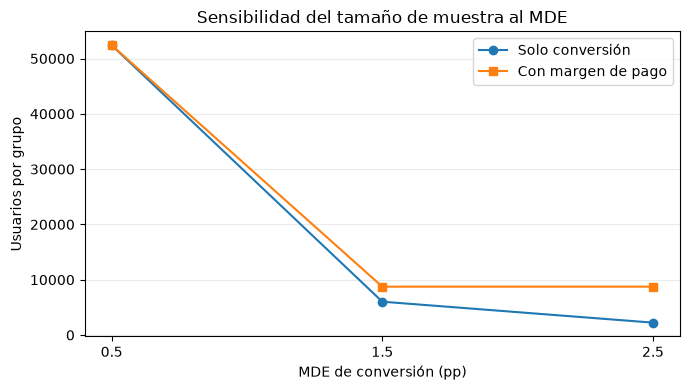

In [7]:
filas = []
for mde in [0.005, 0.015, 0.025]:
    es = proportion_effectsize(BASELINE + mde, BASELINE)
    n = analysis.solve_power(effect_size=es, alpha=ALPHA,
                             power=POTENCIA, alternative="larger")
    filas.append({"MDE_pp": mde * 100,
                  "n_conversion": int(np.ceil(n)),
                  "n_con_guardrail": max(int(np.ceil(n)), n_guardrail)})
sensibilidad_n = pd.DataFrame(filas)
display(sensibilidad_n)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sensibilidad_n["MDE_pp"], sensibilidad_n["n_conversion"], "o-", label="Solo conversión")
ax.plot(sensibilidad_n["MDE_pp"], sensibilidad_n["n_con_guardrail"], "s-", label="Con margen de pago")
ax.set(xlabel="MDE de conversión (pp)", ylabel="Usuarios por grupo",
       title="Sensibilidad del tamaño de muestra al MDE")
ax.set_xticks(sensibilidad_n["MDE_pp"])
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


**Interpretación de la tabla y gráfico — sensibilidad al MDE.** Para +0,5 pp se requieren **52 413** usuarios por grupo y manda conversión. Para +1,5 pp y +2,5 pp, conversión pediría **6 027** y **2 241**, pero el margen de pagos mantiene el plan en **8 743**. El gráfico muestra ese piso y no modifica el MDE preregistrado.

### Pausa de análisis 3 — Respuestas
1. Al reducir el MDE de 1,5 a 0,5 pp, la muestra de conversión sube de 6 027 a 52 413 por grupo; una diferencia pequeña necesita menor error estándar para detectarse con α = 0,05 y potencia 80 %.
2. Con MDE de 1,5 o 2,5 pp, la planificación por conversión pide menos de 8 743; la precisión para el margen de incidencias fija el máximo. Con MDE de 0,5 pp, manda conversión.
3. No sería válido aumentarlo después de ver datos para declarar éxito. MDE, umbral empresarial y regla de decisión tienen funciones distintas y se fijan antes del análisis.


## Actividad 5 — Análisis estadístico de la comparación A/B

**Propósito:** calcular el efecto observado y evaluar la hipótesis mediante una prueba para dos proporciones.

### Paso 6. Obtener tasas y tamaño del efecto observado

Antes de ejecutar, recuerde:

- Diferencia absoluta: $p_B-p_A$.
- Lift relativo: $(p_B-p_A)/p_A$.
- La diferencia se expresa en puntos porcentuales; el lift expresa un cambio relativo respecto de A.


In [8]:
tabla = ab.groupby("grupo")["compra_7d"].agg(["sum", "count", "mean"])
tabla.columns = ["compras", "n", "tasa_conversion"]
x_A, n_A = int(tabla.loc["A_Control", "compras"]), int(tabla.loc["A_Control", "n"])
x_B, n_B = int(tabla.loc["B_Tratamiento", "compras"]), int(tabla.loc["B_Tratamiento", "n"])
p_A, p_B = x_A / n_A, x_B / n_B
efecto = p_B - p_A
lift_rel = efecto / p_A if p_A > 0 else np.nan
display(tabla)
print(f"Diferencia B−A: {efecto*100:.3f} pp")
print(f"Lift relativo: {lift_rel:.2%}")


,compras,n,tasa_conversion
grupo,,,
A_Control,996,8743,0.11392
B_Tratamiento,1236,8743,0.14137


Diferencia B−A: 2.745 pp
Lift relativo: 24.10%


**Interpretación de la salida — conversión descriptiva.** A registra **996/8 743 = 11,392 %** y B **1 236/8 743 = 14,137 %**. La mejora puntual es **+2,745 pp**; el lift de **+24,10 %** usa A como denominador. El lift es relativo, no se expresa en puntos porcentuales. La diferencia observada debe evaluarse con incertidumbre y con los guardrails.

### Pausa de análisis 4 — Respuesta descriptiva, antes del p-valor
La tasa de B es **14,137 %** y la de A es **11,392 %**. La diferencia observada es **+2,745 puntos porcentuales**, equivalente a un **lift relativo de +24,10 %** respecto de A. Estos valores describen la muestra simulada, pero todavía no permiten afirmar que la mejora sea estadísticamente convincente ni que se cumplan los guardrails.


### Paso 7. Contraste e intervalos coherentes
Usamos la aproximación normal de Wald con error estándar no combinado. Se comprueba que haya al menos diez compras y diez no compras en cada grupo; esta regla práctica no sustituye la revisión del diseño.

Para la prueba unilateral frente a cero, p < 0,05 equivale a límite inferior unilateral del 95 % > 0 con el mismo método. El IC bilateral del 95 % se presenta aparte. La función también permite contrastar un umbral distinto de cero. El p-valor no es la probabilidad de que H0 sea verdadera.


In [9]:
def diferencia_wald(x_b, n_b, x_a, n_a, umbral=0.0):
    if min(x_b, n_b-x_b, x_a, n_a-x_a) < 10:
        raise ValueError("Frecuencias pequeñas: revisar método antes de continuar")
    pb, pa = x_b/n_b, x_a/n_a
    d = pb-pa
    se = np.sqrt(pb*(1-pb)/n_b + pa*(1-pa)/n_a)
    z = (d-umbral)/se
    return {"d": d, "se": se, "z": z,
            "p_mayor": norm.sf(z), "p_menor": norm.cdf(z),
            "li_uni95": d-norm.ppf(1-ALPHA)*se,
            "ls_uni95": d+norm.ppf(1-ALPHA)*se,
            "ic95_low": d-norm.ppf(1-ALPHA/2)*se,
            "ic95_high": d+norm.ppf(1-ALPHA/2)*se}

conv = diferencia_wald(x_B, n_B, x_A, n_A)
negocio = diferencia_wald(x_B, n_B, x_A, n_A, UMBRAL_NEGOCIO)
print(f"z frente a cero: {conv['z']:.4f}")
print(f"p unilateral frente a cero: {conv['p_mayor']:.6g}")
print(f"Límite inferior unilateral 95%: {conv['li_uni95']*100:.3f} pp")
print(f"IC bilateral 95%: [{conv['ic95_low']*100:.3f}, {conv['ic95_high']*100:.3f}] pp")
print(f"p unilateral frente a +1,0 pp: {negocio['p_mayor']:.6g}")


z frente a cero: 5.4436
p unilateral frente a cero: 2.61091e-08
Límite inferior unilateral 95%: 1.916 pp
IC bilateral 95%: [1.757, 3.733] pp
p unilateral frente a +1,0 pp: 0.000269553


**Interpretación de la salida — contraste.** El z de **5,4436** y p unilateral **2,61×10⁻⁸** rechazan H₀ de ausencia de mejora al 5 %. El límite inferior unilateral es **+1,916 pp**, superior al mínimo empresarial de +1,0 pp; el IC bilateral 95 % es **[+1,757; +3,733] pp**. El p frente a +1,0 pp es **0,000270**. Es evidencia estadística en el caso simulado, aún insuficiente para desplegar B sin proteger los guardrails.

### Visualización del efecto
El punto representa B−A; la línea muestra el IC bilateral del 95 %. Las referencias marcan cero y el mínimo empresarial de +1,0 pp.

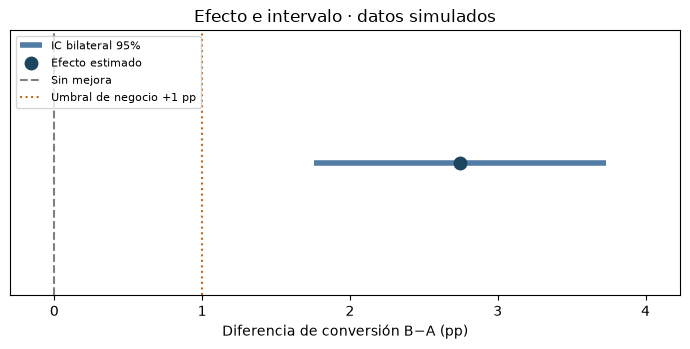

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hlines(1, conv["ic95_low"]*100, conv["ic95_high"]*100, color="#527ca3", linewidth=4,
          label="IC bilateral 95%")
ax.plot(conv["d"]*100, 1, "o", color="#1c455f", markersize=9, label="Efecto estimado")
ax.axvline(0, color="gray", linestyle="--", label="Sin mejora")
ax.axvline(UMBRAL_NEGOCIO*100, color="#bf6b20", linestyle=":", label="Umbral de negocio +1 pp")
ax.set(xlabel="Diferencia de conversión B−A (pp)", title="Efecto e intervalo · datos simulados")
ax.set_yticks([])
ax.set_xlim(-0.3, conv["ic95_high"]*100+0.5)
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

**Interpretación del gráfico — efecto de conversión.** La estimación (+2,745 pp) y todo el IC bilateral 95 % quedan a la derecha de cero y de +1,0 pp. Las líneas verticales representan referencias distintas: cero responde a significancia estadística; +1,0 pp responde a relevancia empresarial.

**Visualización de tasas.** Se muestran las tasas observadas de conversión de A y B con eje porcentual desde cero.

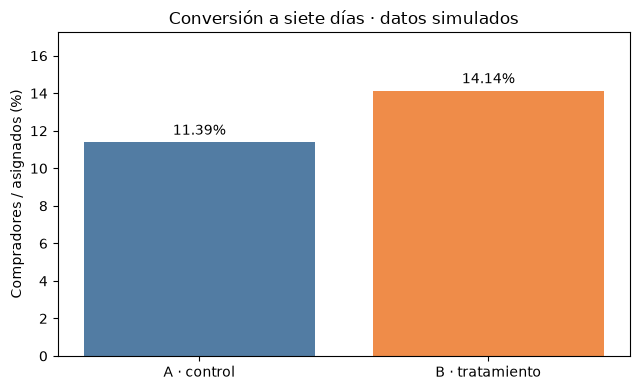

In [11]:
grafico = tabla.reset_index()
grafico["conversion_pct"] = grafico["tasa_conversion"] * 100
fig, ax = plt.subplots(figsize=(6.5, 4))
barras = ax.bar(["A · control", "B · tratamiento"], grafico["conversion_pct"],
                color=["#527ca3", "#ef8c49"])
ax.bar_label(barras, fmt="%.2f%%", padding=3)
ax.set(ylabel="Compradores / asignados (%)", title="Conversión a siete días · datos simulados")
ax.set_ylim(0, max(grafico["conversion_pct"]) * 1.22)
plt.tight_layout()
plt.show()


**Interpretación del gráfico — tasas de conversión.** La barra B es mayor que A: **14,14 % frente a 11,39 %**. El eje inicia en cero para mostrar las magnitudes de ambas tasas. La gráfica resume el punto observado, mientras el gráfico anterior muestra su incertidumbre.

### Análisis y conclusión estadística — Respuestas
1. Con α = 0,05, el estadístico Wald es **z = 5,4436** y el p unilateral frente a cero es **2,61 × 10⁻⁸**.
2. Se rechaza H₀: pB−pA ≤ 0 con el método previsto. Los datos simulados dan evidencia de mayor conversión bajo B; esto no valida causalidad fuera de las condiciones del experimento simulado.
3. El límite inferior unilateral del 95 % es **+1,916 pp**: supera cero y el umbral empresarial de **+1,0 pp**. El p unilateral frente al umbral es **0,000270**.
4. El IC bilateral del 95 % es **[+1,757; +3,733] pp**. Usa el cuantil normal 1,96 para repartir α entre dos colas, mientras el límite unilateral usa 1,645 para una sola cola; por eso no coinciden sus extremos.
5. Un punto estimado mayor que +1,0 pp no bastaría por sí solo. Aquí el límite inferior también supera +1,0 pp, lo que sí satisface esa parte de la regla, sujeto al método y sus supuestos.

El p-valor mide cuán incompatibles serían datos al menos tan extremos con H₀ bajo el modelo; **no** es la probabilidad de que H₀ sea verdadera. Un error Tipo I sería proclamar mejora inexistente; un error Tipo II sería no detectar una mejora real del tamaño planificado.


## Actividad 6 — Del resultado estadístico a la decisión
### Paso 8. Evaluar el guardrail con incertidumbre
El guardrail es la proporción de usuarios con alguna incidencia de pago en siete días. El margen de deterioro admisible es +0,5 pp. La no inferioridad exige que el límite superior unilateral del 95 % esté por debajo de ese margen. No basta obtener p > 0,05 en una prueba de igualdad.

Además del margen relativo B−A, se revisa el tope absoluto **≤ 2 %**
de incidencias entre todos los asignados a B. Se muestra la tasa puntual y
un límite superior unilateral Wilson del 95 %; no se confunden esos dos
criterios.


In [12]:
guardrail = ab.groupby("grupo")["incidencia_pago_7d"].agg(["sum", "count", "mean"])
guardrail.columns = ["incidencias", "n", "tasa_incidencia"]
g_A = int(guardrail.loc["A_Control", "incidencias"])
g_B = int(guardrail.loc["B_Tratamiento", "incidencias"])
guard = diferencia_wald(g_B, n_B, g_A, n_A, MARGEN_GUARDRAIL)
display(guardrail)
li_pago_B, ls_pago_B = proportion_confint(g_B, n_B, alpha=2*ALPHA, method="wilson")
print(f"Pago B: {g_B/n_B*100:.3f}% (límite superior unilateral Wilson 95%: {ls_pago_B*100:.3f}%; tope: {UMBRAL_PAGOS*100:.1f}%)")
print(f"Cambio del guardrail B−A: {guard['d']*100:.3f} pp")
print(f"Límite superior unilateral 95%: {guard['ls_uni95']*100:.3f} pp")
print(f"Margen permitido: {MARGEN_GUARDRAIL*100:.1f} pp")
print(f"p de no inferioridad: {guard['p_menor']:.6g}")


,incidencias,n,tasa_incidencia
grupo,,,
A_Control,139,8743,0.015898
B_Tratamiento,176,8743,0.020130


Pago B: 2.013% (límite superior unilateral Wilson 95%: 2.275%; tope: 2.0%)
Cambio del guardrail B−A: 0.423 pp
Límite superior unilateral 95%: 0.754 pp
Margen permitido: 0.5 pp
p de no inferioridad: 0.351286


**Interpretación de la salida — incidencias de pago.** A registra **139/8 743 = 1,590 %** y B **176/8 743 = 2,013 %**; el cambio puntual es **+0,423 pp**. El límite superior unilateral de B−A es **+0,754 pp**, mayor que el margen +0,5 pp (p de no inferioridad **0,351**): **no se demuestra protección**. B también supera por poco el tope puntual de **2 %** y su límite superior Wilson es **2,275 %**. Esto impide recomendar B, aunque no prueba por sí solo que el verdadero deterioro exceda +0,5 pp.

### Devoluciones a siete días · guardrail adicional
Se simulan solo entre usuarios que compraron. La tasa B se compara con el tope
**≤ 4 %**; la diferencia B−A se reporta de forma descriptiva. La muestra no
se calculó para asegurar precisión de este criterio, por lo que una falta de
certificación no demuestra automáticamente daño.

In [13]:
devoluciones = ab.groupby("grupo").agg(
    compras=("compra_7d", "sum"), devoluciones=("devolucion_7d", "sum"))
devoluciones["tasa_devolucion"] = devoluciones["devoluciones"] / devoluciones["compras"]
d_A = int(devoluciones.loc["A_Control", "devoluciones"])
d_B = int(devoluciones.loc["B_Tratamiento", "devoluciones"])
ret = diferencia_wald(d_B, x_B, d_A, x_A)
li_dev_B, ls_dev_B = proportion_confint(d_B, x_B, alpha=2*ALPHA, method="wilson")
display(devoluciones)
print(f"Diferencia de devoluciones B−A: {ret['d']*100:+.3f} pp")
print(f"IC bilateral Wald 95% de la diferencia: [{ret['ic95_low']*100:+.3f}, {ret['ic95_high']*100:+.3f}] pp")
print(f"B: {d_B/x_B*100:.3f}% (límite superior unilateral Wilson 95%: {ls_dev_B*100:.3f}%; tope: {UMBRAL_DEVOLUCIONES*100:.1f}%)")

,compras,devoluciones,tasa_devolucion
grupo,,,
A_Control,996,28,0.028112
B_Tratamiento,1236,41,0.033172


Diferencia de devoluciones B−A: +0.506 pp
IC bilateral Wald 95% de la diferencia: [-0.926, +1.938] pp
B: 3.317% (límite superior unilateral Wilson 95%: 4.262%; tope: 4.0%)


**Interpretación de la salida — devoluciones.** Entre compradores, A tiene **28/996 = 2,811 %** y B **41/1 236 = 3,317 %**. La diferencia puntual es **+0,506 pp**, con IC bilateral 95 % **[−0,926; +1,938] pp**, compatible tanto con mejora como con deterioro. B queda debajo de 4 % como estimación puntual, pero su límite superior unilateral Wilson es **4,262 %**: **no se certifica** el tope. Este criterio adicional no tiene potencia garantizada en el diseño original.

### Comparación visual de guardrails
Los denominadores son distintos: usuarios asignados para pago y compradores para devoluciones. El triángulo indica el límite superior unilateral del 95 % de B.

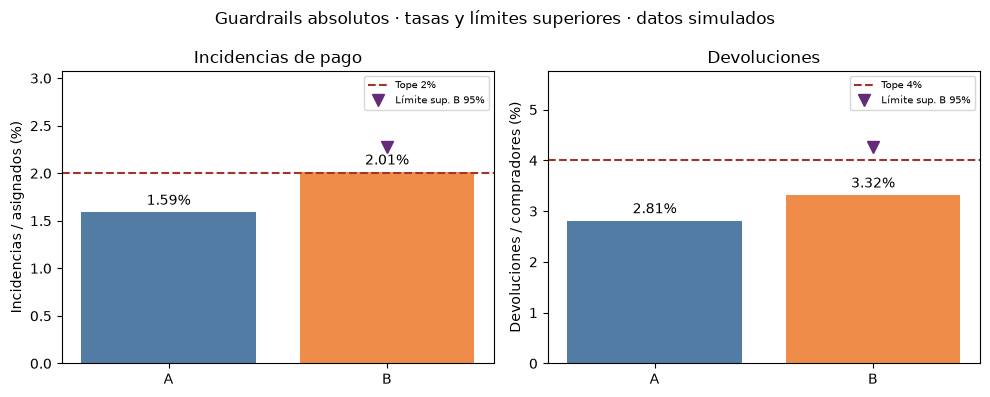

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
for ax, rates, upper, threshold, title, ylabel in [
    (axs[0], guardrail["tasa_incidencia"]*100, ls_pago_B*100,
     UMBRAL_PAGOS*100, "Incidencias de pago", "Incidencias / asignados (%)"),
    (axs[1], devoluciones["tasa_devolucion"]*100, ls_dev_B*100,
     UMBRAL_DEVOLUCIONES*100, "Devoluciones", "Devoluciones / compradores (%)")]:
    bars = ax.bar(["A", "B"], rates, color=["#527ca3", "#ef8c49"])
    ax.bar_label(bars, fmt="%.2f%%", padding=3)
    ax.axhline(threshold, color="#a3342a", linestyle="--", label=f"Tope {threshold:g}%")
    ax.plot(1, upper, "v", color="#642c77", markersize=9, label="Límite sup. B 95%")
    ax.set(title=title, ylabel=ylabel)
    ax.set_ylim(0, max(float(rates.max()), upper, threshold)*1.35)
    ax.legend(fontsize=7)
fig.suptitle("Guardrails absolutos · tasas y límites superiores · datos simulados")
plt.tight_layout()
plt.show()

**Interpretación del gráfico — guardrails.** En pago, la barra B está ligeramente sobre la línea roja de **2 %** y el triángulo de incertidumbre llega a **2,275 %**. En devoluciones, la barra B queda bajo **4 %**, pero el triángulo llega a **4,262 %**. Las dos tasas usan denominadores diferentes, por lo que no deben compararse entre sí como si midieran el mismo riesgo.

### Paso 9. Integrar la regla de decisión
| Criterio fijado antes de simular | Evidencia requerida |
|---|---|
| Diseño y calidad | Usuario único, muestra planificada y seguimiento completo |
| Mejora frente a cero | p unilateral < 0,05 |
| Relevancia empresarial | Límite inferior unilateral 95 % de conversión B−A > +1,0 pp |
| Margen de pago | Límite superior unilateral 95 % de incidencia B−A < +0,5 pp |
| Tope absoluto de pago B | Límite superior unilateral Wilson 95 % ≤ 2 % de los asignados a B |
| Tope absoluto de devoluciones B | Límite superior unilateral Wilson 95 % ≤ 4 % de los compradores en B |

El MDE (+1,5 pp) dimensiona la muestra y no reemplaza al mínimo empresarial.
Los dos topes absolutos se revisan también como tasas puntuales. Los límites
individuales no constituyen una región de confianza simultánea del 95 %.
La muestra no se dimensionó específicamente para el tope de devoluciones.
Si falla un requisito, se distingue falta de evidencia de perjuicio demostrado;
no se continúa agregando usuarios hasta obtener un p favorable.


In [15]:
cumple_estadistica = bool(conv["p_mayor"] < ALPHA)
cumple_negocio = bool(conv["li_uni95"] > UMBRAL_NEGOCIO)
cumple_guardrail = bool(guard["ls_uni95"] < MARGEN_GUARDRAIL)
cumple_pagos_abs = bool(ls_pago_B <= UMBRAL_PAGOS)
cumple_devoluciones = bool(ls_dev_B <= UMBRAL_DEVOLUCIONES)
cumple_diseno = bool((tam_grupos >= N_POR_GRUPO).all())
criterios = pd.Series({"Diseño validado": cumple_diseno,
    "Mejora frente a cero": cumple_estadistica,
    "Mejora superior al umbral": cumple_negocio,
    "Margen de pago protegido": cumple_guardrail,
    "Pago B ≤ 2% con incertidumbre": cumple_pagos_abs,
    "Devoluciones B ≤ 4% con incertidumbre": cumple_devoluciones})
display(criterios.to_frame("cumple"))
if criterios.all():
    decision = "Recomendar B en el caso simulado, con seguimiento posterior."
else:
    decision = "No recomendar el despliegue todavía: revisar los criterios no cumplidos."
print(decision)
print("Conclusión académica con datos simulados; no valida un despliegue real.")


,cumple
Diseño validado,True
Mejora frente a cero,True
Mejora superior al umbral,True
Margen de pago protegido,False
Pago B ≤ 2% con incertidumbre,False
Devoluciones B ≤ 4% con incertidumbre,False


No recomendar el despliegue todavía: revisar los criterios no cumplidos.
Conclusión académica con datos simulados; no valida un despliegue real.


**Interpretación de la salida — decisión conjunta.** El diseño básico, la mejora frente a cero y el mínimo empresarial pasan; los tres criterios de seguridad no quedan acreditados. **No recomendar desplegar B** con este caso simulado. La decisión se fundamenta en la regla previa, no en cambiar α, MDE o semilla después de conocer el resultado. Un estudio nuevo podría planificar precisión y potencia para ambos guardrails.

### Pausa de decisión — Respuestas
| Componente | Resultado observado | Interpretación |
|---|---|---|
| p unilateral frente a cero | 2,61×10⁻⁸ < 0,05 | Evidencia de mayor conversión en B bajo el modelo. |
| Conversión B−A y lift | +2,745 pp; +24,10 % relativo | Mejora puntual de magnitud empresarial relevante. |
| Límite inferior y mínimo empresarial | +1,916 pp > +1,0 pp | La mejora mínima queda sustentada con el criterio unilateral. |
| Margen de pago | Límite superior B−A +0,754 pp > +0,5 pp | No se demuestra no inferioridad en incidencias. |
| Topes absolutos | Pago B 2,013 % y límite 2,275 % frente a 2 %; devolución B 3,317 % y límite 4,262 % frente a 4 % | Pago excede el tope puntual; devoluciones cumplen puntualmente, pero el límite no certifica el tope. |
| Calidad y límites | 8 743 por grupo, seguimiento completo; respuestas simuladas | Diseño estructural consistente, sin validez externa demostrada. |

**Decisión en cuatro líneas.** No recomendar todavía la versión B.La conversión mejora +2,745 pp y supera el mínimo empresarial con límite inferior +1,916 pp.El límite superior del deterioro en pago es +0,754 pp frente al máximo +0,5 pp, y B registra 2,013 % frente al tope absoluto de 2 %.La tasa de devolución B es 3,317 %, pero su límite superior 4,262 % impide confirmar el límite de 4 %; se necesita un experimento nuevo planificado para estos guardrails.

**Límites de inferencia.** La simulación fija probabilidades y siete días de observación; no representa estacionalidad, cambios de tráfico, dependencia entre compra e incidencia ni comportamiento real de devoluciones. Mirar resultados parciales y detener temprano (*peeking*) infla el error Tipo I si el plan no es secuencial. Si un usuario ve A y B, hay contaminación y se compromete la atribución causal. Probar muchos segmentos, métricas o semillas y reportar solo los favorables multiplica falsos positivos; aquí la conversión es la métrica primaria y los guardrails son criterios conjuntos previamente declarados. Un resultado no significativo en seguridad significa evidencia insuficiente, no garantía de ausencia de daño.


## Actividad 7 — Retos de aplicación y retroalimentación
### Reto 1 — Estimación y umbral
Con p = 0,02 frente a cero se rechaza una hipótesis de ausencia de mejora al 5 %, bajo la prueba elegida. Una mejora estimada de +0,4 pp **no demuestra** superar el mínimo empresarial de +3 pp. El intervalo muestra qué tamaños de efecto son compatibles con los datos y si el límite inferior supera +3 pp; sin el intervalo concreto no se puede sostener esa afirmación.

### Reto 2 — Cambio de pregunta
Si interesa cualquier diferencia: H₀: pB−pA = 0; H₁: pB−pA ≠ 0; contraste bilateral. Se escoge antes de mirar datos para no elegir la cola que produce el p más favorable y alterar el error Tipo I.

### Reto 3 — Guardrail no concluyente
No se ha demostrado cumplir el margen: el límite superior de +0,7 pp supera +0,5 pp, aunque el punto sea +0,2 pp. Tampoco se ha demostrado perjuicio solo por ese límite: todavía son compatibles tanto daños mayores que el margen como diferencias menores. Se requiere un experimento nuevo, planificado con precisión suficiente.

### Reto 4 — Reproducibilidad y sesgo
Cambiar la semilla hasta obtener una decisión favorable selecciona un resultado entre muchos ensayos y falsea la evidencia. La semilla del caso base queda fija. Una sensibilidad legítima se documenta aparte, con escenarios y parámetros declarados, todas las salidas visibles y sin sustituir la decisión del caso base.


# VIII. Secuencia de trabajo para la sesión
| Momento | Minutos | Desarrollo |
|---|---:|---|
| Apertura | 10 | Pregunta orientadora y caso |
| Actividad 1 | 15 | Activación conceptual |
| Actividad 2 | 20 | Representación e hipótesis |
| Actividad 3 | 30 | Planificación, simulación y calidad |
| Receso | 15 | Pausa |
| Actividad 4 | 25 | Sensibilidad de muestra |
| Actividad 5 | 30 | Tasas, contraste e intervalos |
| Actividad 6 | 20 | Guardrail y decisión |
| Actividad 7 | 15 | Retos y ticket de salida |

Total: 180 minutos, incluido el receso.

## Ticket de salida
«Un experimento A/B no termina en el p-valor porque…».


# IX. Lista de verificación de aprendizaje
- [x] Identifico factor, niveles y unidad experimental.
- [x] Defino respuesta, denominador y ventana de observación.
- [x] Formulo hipótesis antes de observar resultados.
- [x] Distingo baseline, MDE, umbral empresarial, alfa y potencia.
- [x] Calculo muestra antes de generar los datos del caso.
- [x] Interpreto pp, lift, p-valor e intervalos sin confundirlos.
- [x] Evalúo el guardrail con margen e incertidumbre.
- [x] Distingo evidencia insuficiente de evidencia de perjuicio.
- [x] Reconozco peeking, contaminación y selección de resultados.
- [x] Declaro el carácter simulado y los límites del ejercicio.


# X. Referencias
- Kohavi, R., Tang, D., y Xu, Y. (2020). Trustworthy Online Controlled Experiments. Cambridge University Press.
- Bruce, P., Bruce, A., y Gedeck, P. (2020). Practical Statistics for Data Scientists, segunda edición. O’Reilly.
- statsmodels. Documentación de NormalIndPower y proportion_effectsize: https://www.statsmodels.org/stable/stats.html
- SciPy. Distribución normal, funciones cdf, sf y ppf: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html

Datos: simulación académica NexaCommerce incluida en el notebook, semilla 20260921. Los datos no proceden de las referencias bibliográficas.
